### Product Return Analysis

In [74]:
#Load libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [75]:
#Load data
orders = pd.read_excel(
    r"C:\Users\joela\OneDrive\Data Analytics Projects\Website projects\04 - Products returned by customers (Analysis and Solution)\New Website version\Products returned data.xlsx",
    sheet_name="Orders"
)

cost = pd.read_excel(
    r"C:\Users\joela\OneDrive\Data Analytics Projects\Website projects\04 - Products returned by customers (Analysis and Solution)\New Website version\Products returned data.xlsx",
    sheet_name="Cost"
)

returns = pd.read_excel(
    r"C:\Users\joela\OneDrive\Data Analytics Projects\Website projects\04 - Products returned by customers (Analysis and Solution)\New Website version\Products returned data.xlsx",
    sheet_name="Returns"
)


## Business Problem

Aurowick, a luxury scented candle business, has recently experienced a significant increase in product returns, resulting in financial losses.

This analysis examines business data to identify the key drivers of product returns and provides actionable recommendations to reduce return rates and associated costs.

The findings will need to be presented in the upcoming bi-monthly business review meeting.


Exploratory Data Analysis

In [76]:
#Join Tables
orders['Order Weight'] = orders['Order Weight'].astype(float)
cost['Order Weight'] = cost['Order Weight'].astype(float)

Data = (
    orders
    .merge(cost, on="Order Weight", how="left")
    .merge(returns, on="Consignment number", how="left")
)

Data['Order Date'] = pd.to_datetime(Data['Order date'])
Data['Year'] = Data['Order Date'].dt.year.astype(str)
Data = Data[Data['Year'] != '2021']
Data['Shipping Cost'] = Data.apply(
    lambda row: row['Shipping Cost'] * 1.15
    if row['Shipping method'] == 'In-house'
    else row['Shipping Cost'],
    axis=1
)

#Returns DataFrame
Returns = Data[Data['Product returned (Y,N)'] == 'Y']
Returns.head()



,Order ID,Customer ID,Order date,Order Value,Order Weight,Return customer,Parcel Service,Packed by,Shipping method,Consignment number,Delivery date_x,Shipping Cost,Packaging Cost,Delivery date_y,"Product returned (Y,N)",Reason for return,Order Date,Year
25120,JAP-186860,CU-2231,2022-01-01,364.285714,12.0,Y,1st Class,Alice Johnson,ABC shipping,GB-26121-A,2022-01-02,4.800,2.0,2022-01-02,Y,Damaged Product,2022-01-01,2022
25124,JAP-909342,CU-4290,2022-01-01,444.428571,15.0,N,Regular,Olivia Brown,ABC shipping,GB-26125-A,2022-01-02,4.800,2.0,2022-01-02,Y,Damaged Product,2022-01-01,2022
25127,JAP-451661,CU-4498,2022-01-01,684.857143,24.0,Y,1st Class,Alice Johnson,In-house,GB-26128-A,2022-01-02,8.625,3.0,2022-01-02,Y,Damaged Packaging,2022-01-01,2022
25129,JAP-800859,CU-2108,2022-01-01,470.857143,16.0,Y,Regular,Clara Davis,In-house,GB-26130-C,2022-01-02,5.520,2.0,2022-01-02,Y,Damaged Packaging,2022-01-01,2022
25130,JAP-258925,CU-4842,2022-01-01,578.285714,20.0,Y,1st Class,Bob Smith,In-house,GB-26131-A,2022-01-02,5.520,2.0,2022-01-02,Y,Damaged Packaging,2022-01-01,2022


1. What is the loss incurred due to product returns?

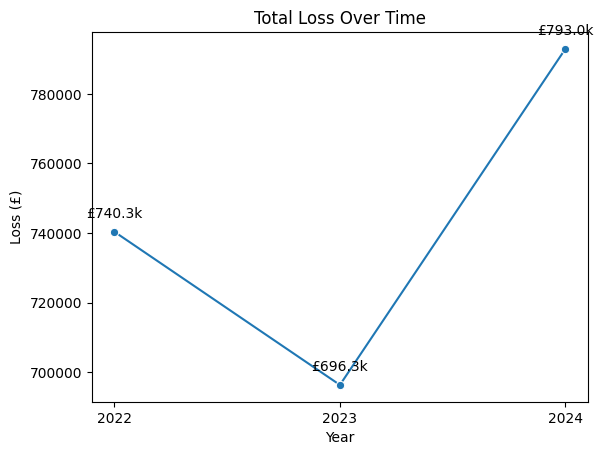

In [ ]:
Revenue_Loss = Returns.copy()

# Calculate loss
Revenue_Loss['Total_Loss'] = Revenue_Loss.apply(
    lambda row:
        row['Order Value'] + row['Shipping Cost'] + row['Packaging Cost']
        if row['Reason for return'] == 'Damaged Product'
        else row['Shipping Cost'] + row['Packaging Cost'],
    axis=1
)

# Ensure Year exists
Revenue_Loss['Year'] = Revenue_Loss['Order Date'].dt.year.astype(str)

# Group by year
Revenue_Loss = Revenue_Loss.groupby('Year')['Total_Loss'].sum().reset_index()
Revenue_Loss.columns = ['Year', 'Total_Loss']

ax = sns.lineplot(
    data=Revenue_Loss,
    x='Year',
    y='Total_Loss',
    marker='o'
)

for x, y in zip(Revenue_Loss['Year'], Revenue_Loss['Total_Loss']):
    ax.annotate(
        f"£{y/1000:.1f}k",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center'
    )

plt.title("Total Loss Over Time")
plt.ylabel("Loss (£)")
plt.show()

Above plot indicates that losses on returns have been increasing since the past 3 years and were the highest in the last year

2. What percentage of orders are returned over the last 3 years?

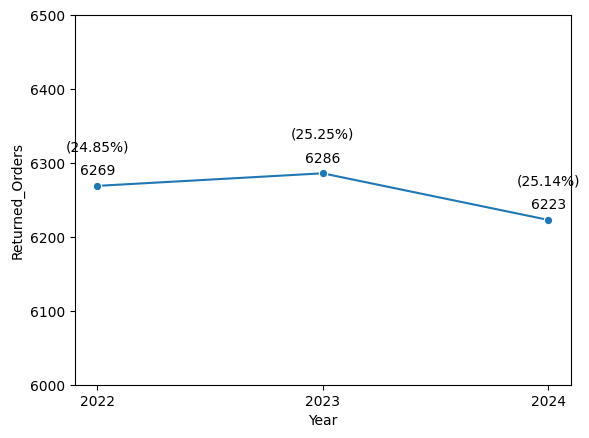

In [78]:
#Calculate return orders

Returned_Orders = Returns.groupby('Year')['Consignment number'].count().reset_index()
Returned_Orders.columns = ['Year', 'Returned_Orders']

#Calculate total orders
Total_Orders = Data.groupby('Year')['Consignment number'].count().reset_index()
Total_Orders.columns = ['Year', 'Total_Orders']

Returned_Orders = Returned_Orders.merge(Total_Orders, on='Year', how='left')

#Calculate percentage of returns
Returned_Orders['percentage of return'] = (Returned_Orders['Returned_Orders']/Returned_Orders['Total_Orders'])*100
Returned_Orders

#Plot
ro = sns.lineplot(data = Returned_Orders,x = 'Year',y = 'Returned_Orders',marker = 'o')
plt.ylim(bottom = 6000,top = 6500)
for i, y in enumerate(Returned_Orders['Returned_Orders']):
    ro.annotate(
        f"{y:.0f}",
        (i, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

# Percentage label
for i, y in enumerate(Returned_Orders['percentage of return']):
    ro.annotate(
        f"({y:.2f}%)",
        (i, Returned_Orders['Returned_Orders'].iloc[i]),  # anchor on bar top
        textcoords="offset points",
        xytext=(0, 25),  # higher offset so it sits above
        ha='center'
    )

plt.show()
plt.show()

On an average over 6000 orders are returned by the customers every year which account for 25% of the total orders shipped

3. What are the major reasons for product returns?

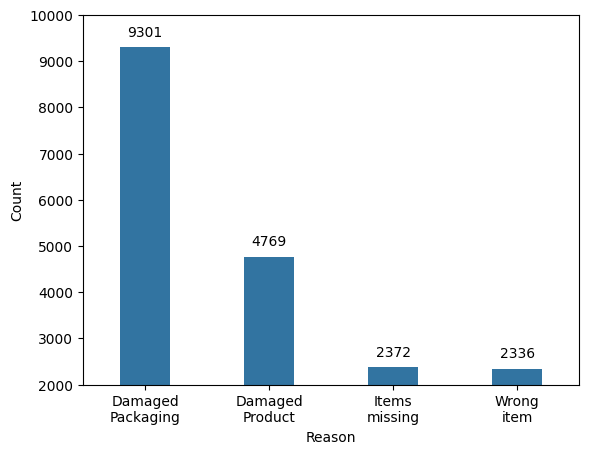

In [79]:
#Prepare return reason table
Reasons = Returns.groupby('Reason for return')['Order ID'].count().reset_index()
Reasons.columns = ['Reason','Count']
Reasons['Reason'] = Reasons['Reason'].str.replace(' ', '\n')
Reasons

#Plot reason for returns
re = sns.barplot(data = Reasons, x = 'Reason', y = 'Count', width = 0.4)
plt.ylim(bottom = 2000, top = 10000)
for i, y in enumerate(Reasons['Count']):
    re.annotate(
        f"{y:.0f}",
        (i, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    ) 


Damaged packaging was the major reason for products to be returned, the second major reason that followed was Damaged product. It is important to note that damaged products cannot be resold and creates an additional loss of stock. The major reasons causing the products and packaging to damage need to be explored. The major reasons for damages can be pssoible due to the delivery service speed, the person packaging the delivery or the shipping method used for the delivery.

4. What are the possible patterns identified in high rerturning orders?

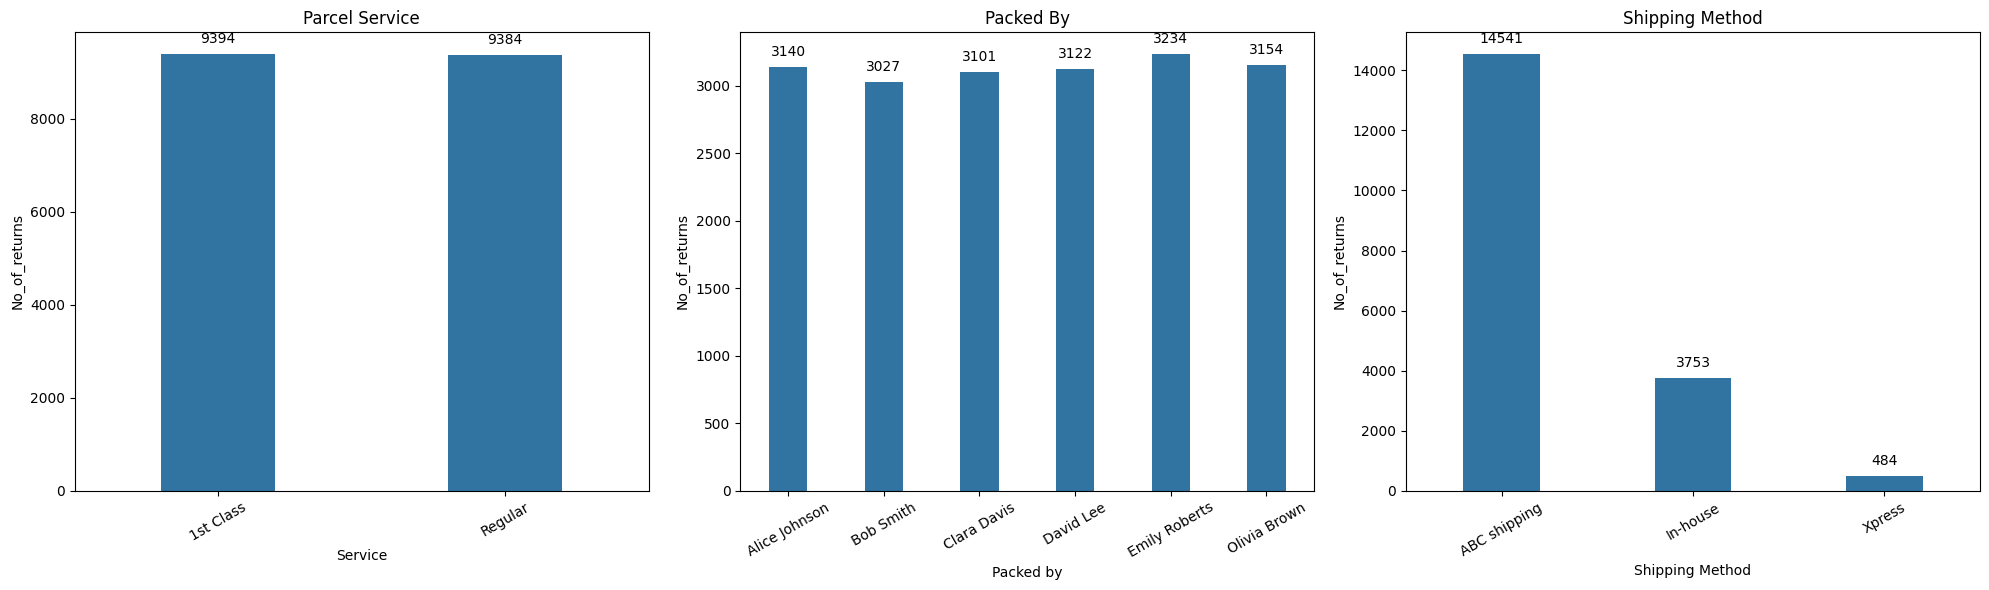

In [80]:
#Returns by parcel service
parcel_service = Returns.groupby('Parcel Service')['Consignment number'].count().reset_index()
parcel_service.columns = ['Service', 'No_of_returns']

#Returns by Packing person
packed_by = Returns.groupby('Packed by')['Consignment number'].count().reset_index()
packed_by.columns = ['Packed by', 'No_of_returns']

#Returns by shipping method
shipping_method = Returns.groupby('Shipping method')['Consignment number'].count().reset_index()
shipping_method.columns = ['Shipping Method', 'No_of_returns']
shipping_method


#Plot all three reason for returns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))


ax = sns.barplot(
    data=parcel_service,
    x='Service',
    y='No_of_returns',
    ax=axes[0],
    width = 0.4
)
axes[0].set_title("Parcel Service")


for i, y in enumerate(parcel_service['No_of_returns']):
    axes[0].annotate(
        f"{y}",
        (i, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )


ax = sns.barplot(
    data=packed_by,
    x='Packed by',
    y='No_of_returns',
    ax=axes[1],
    width = 0.4
)
axes[1].set_title("Packed By")

for i, y in enumerate(packed_by['No_of_returns']):
    axes[1].annotate(
        f"{y}",
        (i, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )


ax = sns.barplot(
    data=shipping_method,
    x='Shipping Method',
    y='No_of_returns',
    ax=axes[2],
    width = 0.4
)
axes[2].set_title("Shipping Method")

for i, y in enumerate(shipping_method['No_of_returns']):
    axes[2].annotate(
        f"{y}",
        (i, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

# Improve layout
for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

The exploration points out a pattern in the shipping method where huge proportion of the damaged  products belong to parcels shipped by ABC shipping limited.

5. What percentage of products were shipped per shipping method and what percentage of products were returned per shipping method?

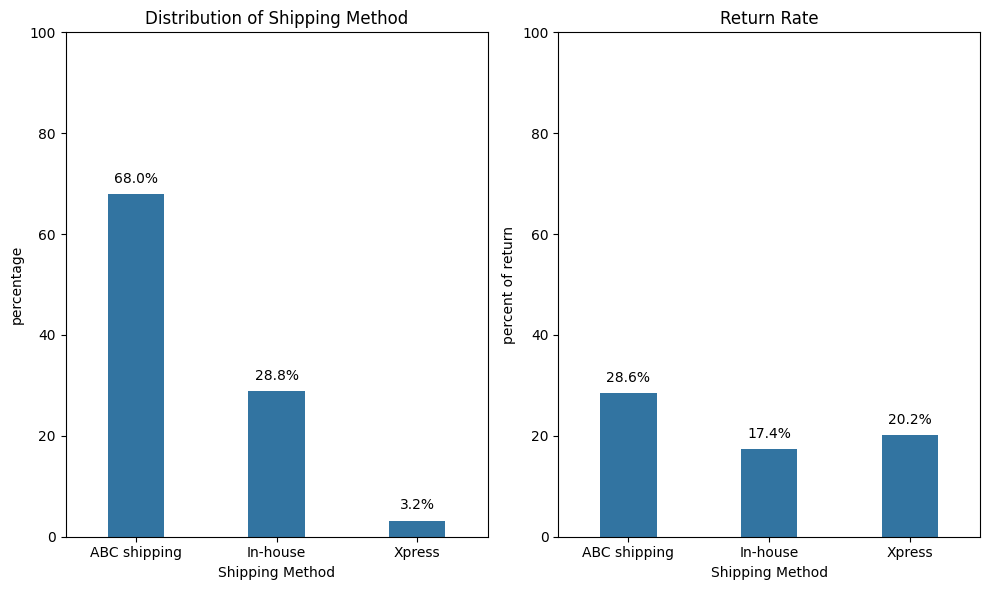

In [81]:
#Calculate percentage distribution of shipping method used

shipping_method_distribution = Data.groupby('Shipping method')['Consignment number'].count().reset_index()
shipping_method_distribution.columns = ['Shipping Method','Count']
shipping_method_distribution['percentage'] = (shipping_method_distribution['Count']/Data['Consignment number'].count())*100
shipping_method_distribution = shipping_method_distribution.merge(shipping_method,on ='Shipping Method', how = 'left')
shipping_method_distribution['percent of return'] = (shipping_method_distribution['No_of_returns']/shipping_method_distribution['Count'])*100
shipping_method_distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# First subplot
sns.barplot(
    data=shipping_method_distribution,
    x='Shipping Method',
    y='percentage',
    ax=axes[0],
    width=0.4
)

axes[0].set_ylim(0, 100)
axes[0].set_title('Distribution of Shipping Method')

for i, y in enumerate(shipping_method_distribution['percentage']):
    axes[0].annotate(
        f"{y:.1f}%",
        (i, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

# Second subplot
sns.barplot(
    data=shipping_method_distribution,
    x='Shipping Method',
    y='percent of return',
    ax=axes[1],
    width=0.4
)

axes[1].set_ylim(0, 100)
axes[1].set_title('Return Rate')

for i, y in enumerate(shipping_method_distribution['percent of return']):
    axes[1].annotate(
        f"{y:.1f}%",
        (i, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

plt.tight_layout()
plt.show()

ABC shipping ships 68% of the total shipments, however, 29% of the shipments are returned due to damaged packaging and products. Although ABC shipping ships 68% of the total shipments, however, 29% of the shipments are returned due to damaged packaging and products.

6. What are the reasons for return per shipping method?

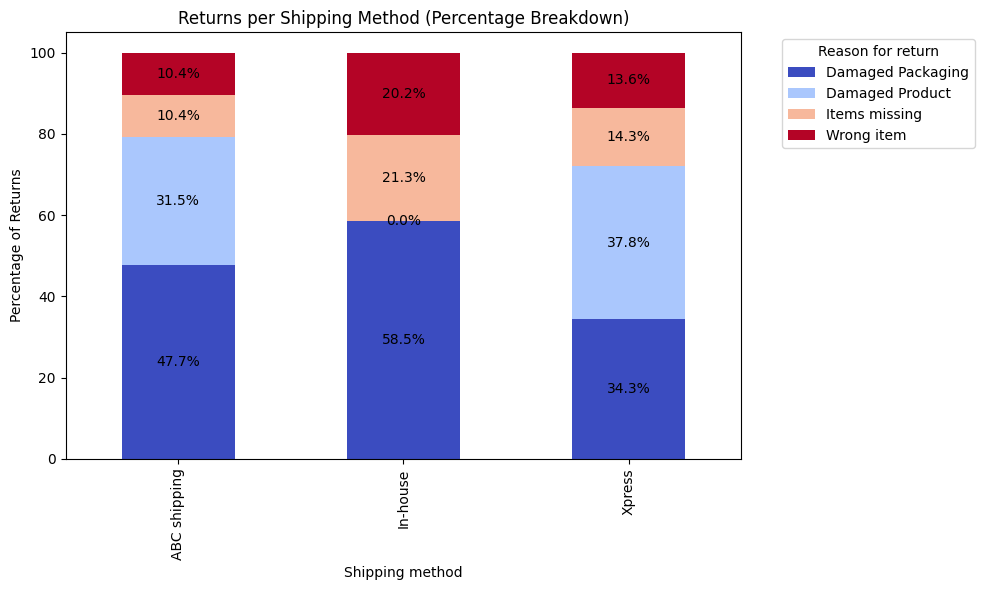

In [82]:
Return_per_shipping_method = Returns.groupby(
    ['Shipping method', 'Reason for return']
)['Consignment number'].count().reset_index()

Return_per_shipping_method.columns = ['Shipping method', 'Reason for return','Count']

Return_per_shipping_method['Percentage'] = (
    Return_per_shipping_method.groupby('Shipping method')['Count']
    .transform(lambda x: (x / x.sum()) * 100)
)
Return_per_shipping_method

ax = pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='coolwarm'
)

plt.ylabel('Percentage of Returns')
plt.title('Returns per Shipping Method (Percentage Breakdown)')
plt.legend(title='Reason for return', bbox_to_anchor=(1.05, 1))

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.tight_layout()
plt.show()

The above image shows that while all 3 shipping methods have caused damaged packaging, In-house shipping method does not cause any damaged products. Here we must also consider that all the proportion of damaged packaging and products for In-house and Xpress methods are higher, the proportion of returned products is much lower compared to ABC shipping.

Statistical Analysis

Analysis suggest that products shipped through ABC shipping are more likely to be returned due to reasons like damaged packaging and damaged products. However, to be sure we need to test this hypothesis statistically. We can form the following hypothesis based on our observations

 

H0 : ABC shipping has a significant positive impact on the return of products

H1 : ABC shipping has no significant positive impact on the return of products.

 

Due to the binary nature of the outcome variable (1- product returned, 0- product not returned), we can use a logistic regression model to test the hypothesis.

In [83]:
#Prepare outcome variable for logistic regression

Data['Returned'] = Data['Product returned (Y,N)'].apply(lambda x : 1 if x == "Y" else 0)
Data['Return_customer_dummy'] = Data['Return customer'].apply(lambda x : 1 if x == "Y" else 0)
Data['Parcel_Regular'] = Data['Parcel Service'].apply(lambda x : 1 if x == 'Regular' else 0)
Data['ABC shipping'] = Data['Shipping method'].apply(lambda x : 1 if x == 'ABC shipping' else 0)
Data['In-house'] = Data['Shipping method'].apply(lambda x : 1 if x == 'In-house' else 0)
Data.head()

,Order ID,Customer ID,Order date,Order Value,Order Weight,Return customer,Parcel Service,Packed by,Shipping method,Consignment number,...,Delivery date_y,"Product returned (Y,N)",Reason for return,Order Date,Year,Returned,Return_customer_dummy,Parcel_Regular,ABC shipping,In-house
25116,JAP-100297,CU-7517,2022-01-01,578.285714,20.0,Y,1st Class,Alice Johnson,ABC shipping,GB-26117-B,...,NaT,NaN,NaN,2022-01-01,2022,0,1,0,1,0
25117,JAP-833670,CU-5127,2022-01-01,846.000000,30.0,Y,1st Class,Olivia Brown,ABC shipping,GB-26118-C,...,NaT,NaN,NaN,2022-01-01,2022,0,1,0,1,0
25118,JAP-607910,CU-3918,2022-01-01,204.000000,6.0,Y,Regular,Alice Johnson,ABC shipping,GB-26119-B,...,NaT,NaN,NaN,2022-01-01,2022,0,1,1,1,0
25119,JAP-259310,CU-2115,2022-01-01,524.571429,18.0,Y,1st Class,Olivia Brown,ABC shipping,GB-26120-A,...,NaT,NaN,NaN,2022-01-01,2022,0,1,0,1,0
25120,JAP-186860,CU-2231,2022-01-01,364.285714,12.0,Y,1st Class,Alice Johnson,ABC shipping,GB-26121-A,...,2022-01-02,Y,Damaged Product,2022-01-01,2022,1,1,0,1,0


In [84]:

# Define X and y
X = Data[['ABC shipping',
          'In-house',
          'Order Value',
          'Order Weight',
          'Return_customer_dummy',
          'Parcel_Regular'
          ]]

Y = Data['Returned']


# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.GLM(Y, X, family=sm.families.Binomial())
results = model.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Returned   No. Observations:                74883
Model:                            GLM   Df Residuals:                    74876
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -41629.
Date:                Mon, 01 Jun 2026   Deviance:                       83258.
Time:                        21:51:05   Pearson chi2:                 7.49e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01440
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.72

ABC shipping method shows a statistically significant positive effect on the return of the products (Beta coeff = 0.50, P<0.05) hence we fail to reject the null hypothesis. This means that sending a product through  ABC shipping increases the log odds of the product being returned by 0.50 points. To understand the effect of the coefficients in terms of percentages  , we need to calculate and plot the average marginal effect of the variables on the outcome.

C:\Users\joela\AppData\Local\Temp\ipykernel_12224\1667233720.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


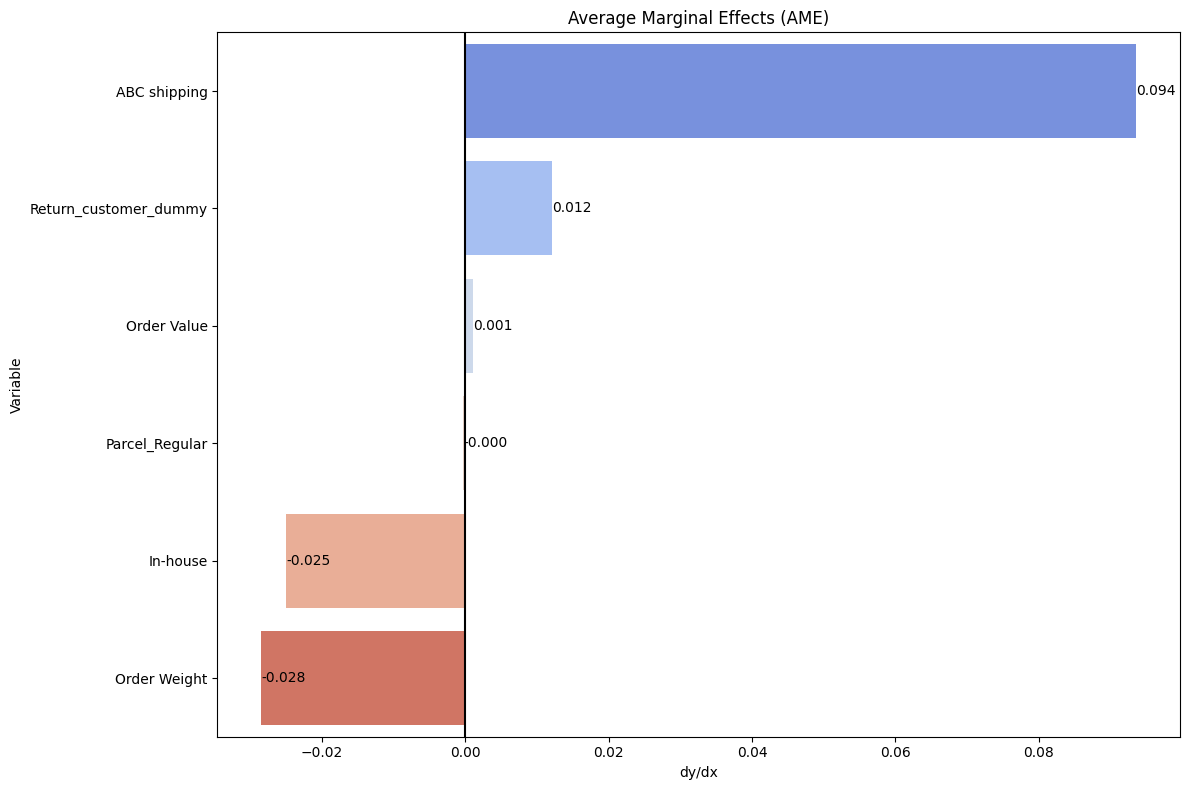

In [85]:
mfx = results.get_margeff(at='overall')
ame_df = mfx.summary_frame()

ame_df = ame_df.reset_index()
ame_df = ame_df.rename(columns={'index': 'Variable'})

# drop constant if it appears
ame_df = ame_df[ame_df['Variable'] != 'const']

ame_df = ame_df.sort_values(by='dy/dx', ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=ame_df,
    x='dy/dx',
    y='Variable',
    palette='coolwarm'
)

ax.axvline(0, color='black')

# add labels (safe method)
for i, v in enumerate(ame_df['dy/dx']):
    ax.text(v, i, f"{v:.3f}", va='center')

plt.title("Average Marginal Effects (AME)")
plt.tight_layout()
plt.show()

ABC shipping has an average marginal effect of 9% which means that a product has a 9% chance of getting returned by the customer if it is shipped through ABC shipping. To understand the accuracy level of the model we can use cross validation techniques and find the accuracy level and the most important variable that affects the outcome of product return. 

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

X_cv = pd.get_dummies(X, drop_first=True)
X_cv = X_cv.fillna(0)

Y_cv = Y

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    model,
    X_cv,
    Y_cv,
    cv=cv,
    scoring='accuracy'
)

print("Accuracy per fold:", scores)
print("Mean accuracy:", scores.mean())

Accuracy per fold: [0.74921546 0.74921546 0.74921546 0.74926549 0.74926549]
Mean accuracy: 0.7492354748078107


Cross validation results suggest that there is 75% accuracy in predicting the output of a product being returned with the help of the model. To further strengthen the analysis, we can build a predictive model that can test scenarios of product return basis the change in the shipping method variable. For this 2 scenarios were fed into a data frame with the only difference being their shipping method opted. following is the output of the scenarios when plotted on a bar graph

In [87]:
scenario1 = pd.DataFrame([{
    'const': 1,
    'ABC shipping': 1,
    'In-house': 0,
    'Order Value': 100,
    'Order Weight': 2,
    'Return_customer_dummy': 1,
    'Parcel_Regular': 0
}])

scenario2 = pd.DataFrame([{
    'const': 1,
    'ABC shipping': 0,
    'In-house': 1,
    'Order Value': 100,
    'Order Weight': 2,
    'Return_customer_dummy': 0,
    'Parcel_Regular': 1
}])

pred1 = results.predict(scenario1)
pred2 = results.predict(scenario2)

print("Scenario 1 probability:", pred1[0])
print("Scenario 2 probability:", pred2[0])

Scenario 1 probability: 0.29146995347193194
Scenario 2 probability: 0.16864057514533368


Keeping all things constant, if we change the shipping method from ABC shipping to an In house shipping method. the chances of the product being returned drops from 29.14% to 16.86%. It is alomost 50% less likely for a product to be returned if we use the in house shipping method.

Cost Benefit Analysis

Changing shipping methods would require a cost to benefit analysis as different shipping methods have different costs and conditions attached to it. Using In-house drivers and vehicles cost 15% more than shipping products through ABC shipping considering fuel costs and salaries for the driver. Xpress shipping method can only ship goods less than 500g which is why it cannot be considered as an alternative method to ABC shipping. Further analysis can be conducted by identifying the current costs incurred by the company and the costs and losses that could possibly be incurred if we move from ABC shipping to In-house shipping methods.

In [117]:
Data1 = (
    orders
    .merge(cost, on="Order Weight", how="left")
    .merge(returns, on="Consignment number", how="left")
)

Data1['Order Date'] = pd.to_datetime(Data1['Order date'])
Data1['Year'] = Data1['Order Date'].dt.year.astype(str)
Data1 = Data1[Data1['Year'] != '2021']


# Calculate cost of sending all products using ABC Shipping and Sending all Products using In-House Shipping
Data1['Returned'] = Data1['Product returned (Y,N)'].apply(lambda x: 1 if x == "Y" else 0)
Data1 = Data1[['Order ID','Order Value','Order Weight','Shipping method','Shipping Cost','Packaging Cost','Returned','Reason for return','Year']]
Data1['ABC Shipping Cost'] = Data1['Shipping Cost'] + Data1['Packaging Cost']
Data1['In-house Cost'] = Data1.apply(
    lambda row:
        row['Shipping Cost'] + row['Packaging Cost']
        if row['Shipping method'] == 'Xpress'
        else row['Shipping Cost'] * 1.15 + row['Packaging Cost'],
    axis=1
)


Data1.head()

,Order ID,Order Value,Order Weight,Shipping method,Shipping Cost,Packaging Cost,Returned,Reason for return,Year,ABC Shipping Cost,In-house Cost
25116,JAP-100297,578.285714,20.0,ABC shipping,4.8,2.0,0,NaN,2022,6.8,7.520
25117,JAP-833670,846.000000,30.0,ABC shipping,7.5,3.0,0,NaN,2022,10.5,11.625
25118,JAP-607910,204.000000,6.0,ABC shipping,3.0,1.0,0,NaN,2022,4.0,4.450
25119,JAP-259310,524.571429,18.0,ABC shipping,4.8,2.0,0,NaN,2022,6.8,7.520
25120,JAP-186860,364.285714,12.0,ABC shipping,4.8,2.0,1,Damaged Product,2022,6.8,7.520


In [98]:
#Cost in case of ABC Shipping
Data1['ABC Shipping Cost'] = Data1['ABC Shipping Cost'].fillna(0)
print(f"ABC Cost: {Data1['ABC Shipping Cost'].sum()}")

#Cost in case of In-house Shipping
Data1['In-house Cost'] = Data1['In-house Cost'].fillna(0)
print(f"In-House Cost: {Data1['In-house Cost'].sum()}")

#Increase in cost
print(f"Difference: {((Data1['In-house Cost'].sum() - Data1['ABC Shipping Cost'].sum())/Data1['ABC Shipping Cost'].sum())*100}%")

ABC Cost: 687690.0
In-House Cost: 761784.2999999999
Difference: 10.774375081795567%


In [111]:
#Profit in Case of ABC Shipping
profit_ABC = Data1['Order Value'].sum() - Data1['ABC Shipping Cost'].sum() - Data1['ABC Shipping Cost'].sum()*0.28 - Data1['Order Value'].sum()*0.28*0.31
profit_in_house = Data1['Order Value'].sum() - Data1['In-house Cost'].sum() - Data1['In-house Cost'].sum()*0.17

print(profit_ABC)
print(profit_in_house)

#Increase in profit
increase_in_profit = ((profit_in_house-profit_ABC)/profit_ABC)*100
print(increase_in_profit)

39862485.54891428
43724052.65471429
9.687221086757292
